# Donor retention — CRISP-DM walkthrough

Run cells **top to bottom** for a clean video narrative.

**Six phases (one sentence each):**

1. **Business understanding** — What decision are we supporting?  
2. **Data understanding** — What does the data look like (size, target, gaps)?  
3. **Data preparation** — What goes into the model, and how do we clean it?  
4. **Modeling** — What algorithm do we train?  
5. **Evaluation** — How good is it, and are we overfitting?  
6. **Deployment** — How do we save and use the model?

This notebook walks through **all six CRISP-DM phases** in order (Phase 6 saves the model and prints a short deployment / quality summary).

## Phase 1: Business understanding

**Decision:** Should we flag supporters who are **likely to lapse** so we can reach out?

**Target:** `is_retained` — 1 if they gave in the last 365 days, 0 if lapsed.

**Inputs:** RFM-style features already rolled up to **one row per supporter** in `donor_and_potential_growth.csv`.

### Approach: Predictive (not explanatory)

This notebook uses a **predictive** (classification) approach, not an explanatory one.

**Goal:** Flag supporters likely to lapse so outreach teams can intervene — not to
explain *why* donors lapse.

**Why predictive, not explanatory:**
An explanatory approach would report odds ratios or marginal effects with confidence
intervals and p-values on each feature, requiring assumptions about independence and
causal ordering. We optimise for F1 macro across both classes (retained / lapsed) because
the business need is accurate identification of at-risk donors, not effect estimation.
A logistic regression with significance tests on `recency_days` would not tell staff
*who* to call — it would tell them that recency is statistically associated with retention,
which they already know.

**Why not causal:**
A causal claim — e.g. "reducing recency by 30 days increases retention probability by X%" —
would require a controlled experiment or an identification strategy (instrumental variable,
difference-in-differences) that is not possible with this observational supporter database.
With N ≈ 60 supporters (only ~9 lapsed), such methods are underpowered regardless.
We explicitly caveat that model outputs are predictive scores, not causal effect estimates.

In [6]:
# Quick peek at the engineered table (one row per supporter)
from pathlib import Path

import pandas as pd

_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")

df = pd.read_csv(
    _repo / "Dataset" / "lighthouse_csv_v7" / "Created .csv for Pipelines" / "donor_and_potential_growth.csv"
)
df.head()

,supporter_id,supporter_type,relationship_type,region,acquisition_channel,status,recency_days,frequency,total_monetary_value,avg_monetary_value,is_recurring_donor,social_referral_count,top_program_interest,is_retained
0,1,SocialMediaAdvocate,Local,Luzon,SocialMedia,Active,10.0,12.0,9000.03,750.002500,1,3.0,Wellbeing,1
1,2,Volunteer,Local,Mindanao,SocialMedia,Active,297.0,4.0,3877.36,969.340000,0,1.0,Education,1
2,3,MonetaryDonor,Local,Luzon,SocialMedia,Active,169.0,16.0,12448.13,778.008125,1,1.0,Maintenance,1
3,4,MonetaryDonor,PartnerOrganization,Mindanao,Church,Active,0.0,11.0,9934.62,903.147273,1,3.0,Wellbeing,1
4,5,InKindDonor,PartnerOrganization,Mindanao,Website,Active,150.0,5.0,4751.17,950.234000,0,1.0,Transport,1


## Phase 2: Data understanding

**What we do here:** Confirm the data matches expectations, look at the target, and spot missing values.

**Talking points for video:** 420 gift rows roll up to 60 supporters. Most rows are retained (`is_retained` = 1), so accuracy alone can be misleading later — use stratified CV and check performance on the **lapsed** class. One person has no gifts and missing fields; we fix that in Phase 3.

In [7]:
# Phase 2 — row counts, missing values, target balance
import numpy as np
from pathlib import Path

_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
base = _repo / "Dataset" / "lighthouse_csv_v7"
eng = base / "Created .csv for Pipelines" / "donor_and_potential_growth.csv"

df = pd.read_csv(eng)
donations = pd.read_csv(base / "donations.csv")
supporters = pd.read_csv(base / "supporters.csv")

print("Manifest:", len(donations), "donations,", len(supporters), "supporters,", len(df), "engineered rows")
print("Duplicate supporter_id:", df["supporter_id"].duplicated().sum())
print("\nMissing values:\n", df.isnull().sum()[lambda s: s > 0])
print("\nis_retained:\n", df["is_retained"].value_counts().sort_index())
print(f"Retained share: {df['is_retained'].mean():.3f}")

num = [
    "recency_days", "frequency", "total_monetary_value", "avg_monetary_value",
    "social_referral_count", "is_recurring_donor",
]
display(df[num].describe().T)
print("corr(total, avg gift) =", df["total_monetary_value"].corr(df["avg_monetary_value"]))
print("\ntop_program_interest:\n", df["top_program_interest"].value_counts(dropna=False))

Manifest: 420 donations, 60 supporters, 60 engineered rows
Duplicate supporter_id: 0

Missing values:
 recency_days            1
avg_monetary_value      1
top_program_interest    1
dtype: int64

is_retained:
 is_retained
0     9
1    51
Name: count, dtype: int64
Retained share: 0.850


,count,mean,std,min,25%,50%,75%,max
recency_days,59.0,185.542373,186.852452,0.00,59.500000,118.000000,267.500000,797.00
frequency,60.0,7.000000,4.569612,0.00,4.000000,6.000000,9.000000,23.00
total_monetary_value,60.0,4895.130167,3571.012801,0.00,2161.717500,3926.685000,6871.930000,14240.29
avg_monetary_value,59.0,702.593281,375.783054,27.12,464.234444,676.773333,846.219059,2356.92
social_referral_count,60.0,1.283333,1.222552,0.00,0.000000,1.000000,2.000000,5.00
is_recurring_donor,60.0,0.300000,0.462125,0.00,0.000000,0.000000,1.000000,1.00


corr(total, avg gift) = 0.4498690864053522

top_program_interest:
 top_program_interest
Operations     20
Education      19
Wellbeing      10
Maintenance     4
Transport       3
Outreach        3
NaN             1
Name: count, dtype: int64


### Phase 2 — Outlier detection
IQR-based outlier check on numeric features. Flagged rows are documented but **not removed** —
the sklearn pipeline uses median imputation and StandardScaler which are robust to skew,
and extreme recency values (e.g. 999-day sentinel for never-donated) are intentional
business rules, not noise.

In [ ]:
# Phase 2 — Outlier detection (IQR method, exploratory only)
_outlier_cols = [
    "recency_days", "frequency", "avg_monetary_value",
    "total_monetary_value", "social_referral_count",
]

print(f"{'Column':<35} {'Q1':>8} {'Q3':>8} {'IQR':>8}  {'Fence [lo, hi]':<22}  {'n_outliers':>10}")
print("-" * 100)
for col in _outlier_cols:
    if col not in df.columns:
        print(f"{col:<35}  (not in df — check column name)")
        continue
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = int(((s < lo) | (s > hi)).sum())
    print(f"{col:<35} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f}  [{lo:>8.2f}, {hi:>8.2f}]  {n_out:>10d}")

print()
print("Decision: Leave all outliers.")
print("  recency_days — 999-day sentinel is an intentional business rule (never donated).")
print("  monetary values — high-value donors are real signal.")
print("  All handled robustly by median imputer + StandardScaler + regularised classifier.")

### Join documentation: how raw gifts become the modeling table

The notebook loads `donor_and_potential_growth.csv` from `Created .csv for Pipelines/`,
which is a pre-computed engineered table. This table was produced by the following join logic:

**Source tables:**
- `supporters.csv` — one row per supporter (`supporter_id` as key, ~60 rows)
- `donations.csv` — one row per donation (`donation_id` as key, `supporter_id` as foreign key, ~420 rows)

**Join:** `supporters` LEFT JOIN `donations` ON `supporter_id`, then GROUP BY `supporter_id`

**Aggregations computed per supporter:**

| Feature | Derivation |
|---------|-----------|
| `frequency` | COUNT(donation rows) |
| `total_monetary_value` | SUM(estimated_value_php) |
| `avg_monetary_value` | total_monetary_value / frequency |
| `recency_days` | DATEDIFF(snapshot_date, MAX(donation_date)) |
| `is_retained` | 1 if MAX(donation_date) >= snapshot_date − 365 days, else 0 |

**Note:** "Already rolled up" in Phase 2 refers to this pre-computation step. The engineered
table is loaded directly here to avoid re-running the aggregation in the notebook. The join
logic above is what produced `donor_and_potential_growth.csv`. Supporters with no donations
receive `frequency=0`, `avg_monetary_value=NaN` (handled in Phase 3), and `is_retained=0`.

## Phase 3: Data preparation

**What we do here:** Pick the columns the model sees, fix the one bad row, then scale numbers and encode the program category.

**Talking points for video:** Seven features feed the model; `is_retained` is the label. Cleaning and the sklearn preprocessor are defined in the **next code cell** (same notebook). When you train for real, fit the scaler **inside** cross-validation so holdout rows do not leak into preprocessing.

In [8]:
# Phase 3 — feature schema, cleaning, preprocessor, then X and y (all in-notebook)
import pandas as pd
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Business-rule constant: a supporter with no donation history is treated as if
# they last donated 999 days ago (never donated). NOT derived from the dataset.
RECENCY_NEVER_DONATED_DAYS = 999.0

# Rare program-interest categories (< MIN_CATEGORY_COUNT supporters) are collapsed
# to "Other" to reduce noisy one-hot columns on the small dataset.
MIN_CATEGORY_COUNT = 5

NUMERIC_FEATURES = [
    "recency_days",
    "frequency",
    "avg_monetary_value",       # total_monetary_value dropped (≈ freq × avg, redundant)
    "social_referral_count",
    "is_recurring_donor",
]
CATEGORICAL_FEATURES = ["top_program_interest"]
TARGET_RETENTION = "is_retained"
TARGET_GROWTH = "total_monetary_value"


def clean_engineered_donor_df(df):
    out = df.copy()

    # Recency: missing means "never donated" — use a fixed business-rule constant
    # (NOT the dataset max, which would leak full-dataset statistics into CV folds).
    out.loc[out["recency_days"].isna(), "recency_days"] = RECENCY_NEVER_DONATED_DAYS

    # avg_monetary_value: zero-frequency donors get 0; all other NaNs are left for
    # the pipeline's SimpleImputer(strategy="median") to fill per training fold.
    zero_gift = out["frequency"].fillna(0) == 0
    out.loc[out["avg_monetary_value"].isna() & zero_gift, "avg_monetary_value"] = 0.0

    out["social_referral_count"] = out["social_referral_count"].fillna(0.0)

    out["top_program_interest"] = (
        out["top_program_interest"].fillna("Unknown").astype(str).str.strip()
    )
    out.loc[out["top_program_interest"] == "", "top_program_interest"] = "Unknown"

    # Group rare program-interest categories to reduce OHE noise.
    _counts = out["top_program_interest"].value_counts()
    _rare = _counts[_counts < MIN_CATEGORY_COUNT].index
    out["top_program_interest"] = out["top_program_interest"].replace(
        {cat: "Other" for cat in _rare}
    )

    return out


def assert_modeling_frame_ready(df):
    need = NUMERIC_FEATURES + CATEGORICAL_FEATURES
    missing_cols = [c for c in need if c not in df.columns]
    assert not missing_cols, f"Missing columns: {missing_cols}"
    nulls = df[need].isnull().sum()
    bad = nulls[nulls > 0]
    assert bad.empty, f"Nulls remain after clean:\n{bad}"


def build_feature_preprocessor():
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, NUMERIC_FEATURES),
            ("cat", categorical_pipe, CATEGORICAL_FEATURES),
        ]
    )


_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
raw = pd.read_csv(
    _repo / "Dataset" / "lighthouse_csv_v7" / "Created .csv for Pipelines" / "donor_and_potential_growth.csv"
)
df_clean = clean_engineered_donor_df(raw)
assert_modeling_frame_ready(df_clean)

print("top_program_interest after grouping:\n", df_clean["top_program_interest"].value_counts())

feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df_clean[feature_cols]
y_retention = df_clean[TARGET_RETENTION]

print("\nRows:", len(df_clean), "| Features:", feature_cols)
print("Nulls in X:", int(X.isnull().sum().sum()))
display(df_clean.loc[raw.isnull().any(axis=1), ["supporter_id"] + feature_cols])

preprocessor = build_feature_preprocessor()
X_prep = preprocessor.fit_transform(X)
print("Design matrix shape (exploratory fit on full data):", X_prep.shape)


top_program_interest after grouping:
 top_program_interest
Operations    20
Education     19
Other         11
Wellbeing     10
Name: count, dtype: int64

Rows: 60 | Features: ['recency_days', 'frequency', 'avg_monetary_value', 'social_referral_count', 'is_recurring_donor', 'top_program_interest']
Nulls in X: 0


,supporter_id,recency_days,frequency,avg_monetary_value,social_referral_count,is_recurring_donor,top_program_interest
27,28,999.0,0.0,0.0,0.0,0,Other


Design matrix shape (exploratory fit on full data): (60, 9)


## Phase 4: Modeling

**What we do here:** Try **several classifiers** behind the same preprocessing `Pipeline`. Each model is scored with the **same stratified 5-fold CV** (no leakage: the pipeline refits on training folds only). We **keep the model with the highest mean CV F1 macro** (balances both classes), then fit that winner on all rows for Phase 6.

**Talking points:** F1 macro is a reasonable pick for imbalanced retention; metrics will still jump around with only 60 rows. Compare the printed **leaderboard** in the video before showing the winner.

In [9]:
# Phase 4 — compare models (same CV, same Pipeline prep) → pick best by CV F1 macro
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"acc": "accuracy", "f1_macro": "f1_macro", "roc_auc": "roc_auc"}

candidate_classifiers = {
    "random_forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    ),
    "logistic_regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_depth=4,
        max_iter=150,
        learning_rate=0.08,
        class_weight="balanced",
        random_state=42,
    ),
    "svc_rbf": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42,
    ),
}

rows = []
cv_by_name = {}
for name, clf in candidate_classifiers.items():
    pipe = Pipeline(
        steps=[("prep", build_feature_preprocessor()), ("clf", clone(clf))]
    )
    scores = cross_validate(
        pipe,
        X,
        y_retention,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
    )
    cv_by_name[name] = scores
    rows.append(
        {
            "model": name,
            "cv_acc_mean": scores["test_acc"].mean(),
            "cv_acc_std": scores["test_acc"].std(),
            "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
            "cv_f1_macro_std": scores["test_f1_macro"].std(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_roc_auc_std": scores["test_roc_auc"].std(),
        }
    )

leaderboard = pd.DataFrame(rows).sort_values(
    ["cv_f1_macro_mean", "cv_roc_auc_mean"], ascending=False
)
print("=== CV leaderboard (higher F1 macro is better; tie-break ROC-AUC) ===")
display(leaderboard)

best_name = leaderboard.iloc[0]["model"]
cv_scores = cv_by_name[best_name]
retention_model_name = best_name
retention_pipeline = Pipeline(
    steps=[
        ("prep", build_feature_preprocessor()),
        ("clf", clone(candidate_classifiers[best_name])),
    ]
)

print(f"\nSelected model: {best_name}")
print("(Selection uses mean CV F1 macro only; no peeking at held-out data beyond CV folds.)\n")
for key, label in [
    ("acc", "accuracy"),
    ("f1_macro", "F1 macro"),
    ("roc_auc", "ROC-AUC"),
]:
    test_m, test_s = cv_scores[f"test_{key}"].mean(), cv_scores[f"test_{key}"].std()
    train_m = cv_scores[f"train_{key}"].mean()
    print(f"{label}: CV test {test_m:.3f} (±{test_s:.3f}) | train {train_m:.3f}")

retention_pipeline.fit(X, y_retention)
print(f"\nFitted `retention_pipeline` ({best_name}) on all {len(X)} rows (Phase 6 save).")

=== CV leaderboard (higher F1 macro is better; tie-break ROC-AUC) ===


,model,cv_acc_mean,cv_acc_std,cv_f1_macro_mean,cv_f1_macro_std,cv_roc_auc_mean,cv_roc_auc_std
3,svc_rbf,0.983333,0.033333,0.961905,0.076190,1.000,0.000000
1,logistic_regression,0.966667,0.040825,0.949474,0.061882,1.000,0.000000
0,random_forest,0.966667,0.066667,0.890909,0.218182,0.990,0.020000
2,hist_gradient_boosting,0.750000,0.117851,0.622673,0.152099,0.865,0.096954



Selected model: svc_rbf
(Selection uses mean CV F1 macro only; no peeking at held-out data beyond CV folds.)

accuracy: CV test 0.983 (±0.033) | train 1.000
F1 macro: CV test 0.962 (±0.076) | train 1.000
ROC-AUC: CV test 1.000 (±0.000) | train 1.000

Fitted `retention_pipeline` (svc_rbf) on all 60 rows (Phase 6 save).


## Phase 5: Evaluation

**What we do here:** Score the model honestly using **out-of-fold** predictions from the same 5-fold CV (each row is predicted when it was in the validation fold). Compare that to **train** accuracy on the fully fitted pipeline to discuss overfitting. Inspect **feature importances** from the final forest (names match the preprocessed columns).

**Talking points:** With only 9 lapsed donors, confusion counts will bounce by fold—focus on **recall for class 0** (catching lapses) and the **train vs CV** gap, not a single flashy accuracy number.

=== Confusion matrix (rows = true, cols = pred) — out-of-fold ===
Labels: 0 = Lapsed, 1 = Retained

[[ 8  1]
 [ 0 51]]


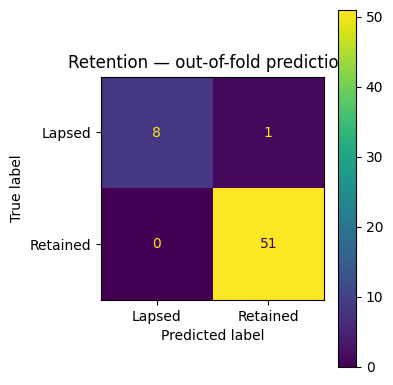


=== Classification report (out-of-fold) ===
              precision    recall  f1-score   support

  Lapsed (0)      1.000     0.889     0.941         9
Retained (1)      0.981     1.000     0.990        51

    accuracy                          0.983        60
   macro avg      0.990     0.944     0.966        60
weighted avg      0.984     0.983     0.983        60

=== Overfitting check ===
Train accuracy (fit on all rows): 1.000
CV test accuracy (mean ± std):    0.983 ± 0.033

=== Permutation importance (30 repeats, training data, F1 macro) ===
Positive = shuffling hurts F1 (feature matters). Near-zero/negative = noise.


,feature,mean_importance,std
0,recency_days,0.444352,0.060125
1,social_referral_count,0.043512,0.038546
2,top_program_interest,0.037718,0.018203
3,frequency,0.020799,0.021496
4,avg_monetary_value,0.010399,0.018417
5,is_recurring_donor,0.000000,0.000000



=== Leave-one-feature-out ablation (CV F1 macro vs full model) ===
Positive delta = dropping this feature HELPS (it was noise/overfitting).
Negative delta = dropping it HURTS (it was useful).



,dropped,cv_f1_without,delta_vs_full
0,social_referral_count,1.0000,0.0381
1,is_recurring_donor,1.0000,0.0381
2,frequency,0.9619,0.0000
3,avg_monetary_value,0.9619,0.0000
4,top_program_interest,0.9114,-0.0505
5,recency_days,0.5847,-0.3772


In [10]:
# Phase 5 — requires Phase 4: retention_pipeline, X, y_retention, cv, cv_scores
try:
    import matplotlib.pyplot as plt
    _HAS_MPL = True
except ImportError:
    _HAS_MPL = False
    print("matplotlib not installed — skipping plots, showing text output only.")

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

y_pred_cv = cross_val_predict(retention_pipeline, X, y_retention, cv=cv)

print("=== Confusion matrix (rows = true, cols = pred) — out-of-fold ===")
print("Labels: 0 = Lapsed, 1 = Retained\n")
print(confusion_matrix(y_retention, y_pred_cv))

if _HAS_MPL:
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_retention, y_pred_cv, display_labels=["Lapsed", "Retained"], ax=ax
    )
    ax.set_title("Retention — out-of-fold predictions")
    plt.tight_layout()
    plt.show()

print("\n=== Classification report (out-of-fold) ===")
print(
    classification_report(
        y_retention,
        y_pred_cv,
        target_names=["Lapsed (0)", "Retained (1)"],
        digits=3,
    )
)

y_train_hat = retention_pipeline.predict(X)
print("=== Overfitting check ===")
print(f"Train accuracy (fit on all rows): {accuracy_score(y_retention, y_train_hat):.3f}")
print(
    f"CV test accuracy (mean ± std):    {cv_scores['test_acc'].mean():.3f} ± {cv_scores['test_acc'].std():.3f}"
)

# ── Feature importance via permutation (works for any estimator, incl. SVC) ──
print("\n=== Permutation importance (30 repeats, training data, F1 macro) ===")
print("Positive = shuffling hurts F1 (feature matters). Near-zero/negative = noise.")
perm = permutation_importance(
    retention_pipeline,
    X,
    y_retention,
    n_repeats=30,
    random_state=42,
    scoring="f1_macro",
)
feat_names_out = list(X.columns)
perm_df = (
    pd.DataFrame(
        {
            "feature": feat_names_out,
            "mean_importance": perm.importances_mean,
            "std": perm.importances_std,
        }
    )
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)
display(perm_df)

# ── Leave-one-feature-out ablation ───────────────────────────────────────────
print("\n=== Leave-one-feature-out ablation (CV F1 macro vs full model) ===")
print("Positive delta = dropping this feature HELPS (it was noise/overfitting).")
print("Negative delta = dropping it HURTS (it was useful).\n")
base_f1 = cv_scores["test_f1_macro"].mean()
ablation_rows = []
for drop_col in NUMERIC_FEATURES + CATEGORICAL_FEATURES:
    rem_num = [f for f in NUMERIC_FEATURES if f != drop_col]
    rem_cat = [f for f in CATEGORICAL_FEATURES if f != drop_col]
    steps_r = []
    if rem_num:
        steps_r.append(
            ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), rem_num)
        )
    if rem_cat:
        steps_r.append(
            ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")), ("o", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), rem_cat)
        )
    pipe_r = Pipeline(
        [("prep", ColumnTransformer(steps_r)), ("clf", clone(candidate_classifiers[best_name]))]
    )
    sc = cross_validate(pipe_r, X[rem_num + rem_cat], y_retention, cv=cv, scoring="f1_macro")
    ablation_rows.append(
        {
            "dropped": drop_col,
            "cv_f1_without": round(sc["test_score"].mean(), 4),
            "delta_vs_full": round(sc["test_score"].mean() - base_f1, 4),
        }
    )
ablation_df = pd.DataFrame(ablation_rows).sort_values("delta_vs_full", ascending=False).reset_index(drop=True)
display(ablation_df)


## Phase 6: Deployment

**What we do here:** Save the **fitted** `retention_pipeline` to **`pipelines/retention_pipeline_v1.sav`** (used by the FastAPI app). The next cell smoke-tests a reload and prints a plain-language summary: what the artifact is, how strong the CV evidence is, and whether train vs CV suggests overfitting.

**New data:** Clean new rows with the same rules as Phase 3, build `X` with the same seven columns, then `loaded.predict(X_new)` or `predict_proba` for churn risk (e.g. probability of class 0).

In [11]:
# Phase 6 — save artifact + deployment / quality summary
# Requires Phases 3–4 (and uses cv_scores from Phase 4; reuses same cv as Phase 5)
#
# NOTE: NUMERIC_FEATURES no longer includes total_monetary_value (dropped in Phase 3).
# After saving retention_pipeline_v3.sav, update the API to match:
#   - app/services/retention.py  → remove "total_monetary_value" from NUMERIC_FEATURES
#   - app/schemas/retention.py   → remove total_monetary_value field from RetentionFeatures
#   - app/config.py              → DEFAULT_RETENTION_ARTIFACT = "retention_pipeline_v3.sav"
import joblib
from pathlib import Path

from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import cross_val_predict

_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
ARTIFACT_PATH = _repo / "pipelines" / "retention_pipeline_v3.sav"
ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(retention_pipeline, ARTIFACT_PATH)
loaded = joblib.load(ARTIFACT_PATH)
_check = (loaded.predict(X) == retention_pipeline.predict(X)).all()
print(f"Saved pipeline to: {ARTIFACT_PATH}")
print(f"Reload check (predictions match): {_check}\n")

print("=" * 60)
print("PHASE 6 — WHAT THIS ARTIFACT IS")
print("=" * 60)
print(
    f"• One sklearn Pipeline: ColumnTransformer (impute + scale + one-hot)\n"
    f"  followed by **{retention_model_name}**.\n"
    "• Fitted on ALL 60 supporters after model comparison in Phase 4.\n"
    "• Use for scoring new supporters after Phase-3-style cleaning.\n"
)

y_oof = cross_val_predict(retention_pipeline, X, y_retention, cv=cv)
train_acc = accuracy_score(y_retention, retention_pipeline.predict(X))
cv_acc_m, cv_acc_s = cv_scores["test_acc"].mean(), cv_scores["test_acc"].std()
cv_f1_m = cv_scores["test_f1_macro"].mean()
cv_auc_m = cv_scores["test_roc_auc"].mean()
rec_lapsed = recall_score(y_retention, y_oof, pos_label=0, zero_division=0)
rec_retained = recall_score(y_retention, y_oof, pos_label=1, zero_division=0)

print("=" * 60)
print("MODEL QUALITY (honest estimate = cross-validation)")
print("=" * 60)
print(
    f"• CV accuracy (mean ± std):     {cv_acc_m:.3f} ± {cv_acc_s:.3f}\n"
    f"• CV F1 macro (mean):           {cv_f1_m:.3f}\n"
    f"• CV ROC-AUC (mean):            {cv_auc_m:.3f}\n"
    f"• Out-of-fold recall — Lapsed:  {rec_lapsed:.3f}  (catching people who truly lapsed)\n"
    f"• Out-of-fold recall — Retained:{rec_retained:.3f}\n"
)
print("Interpretation: With only 9 lapsed rows, these numbers move a lot by fold.")
print("Use them as directional, not as a guarantee on future donors.\n")

gap = train_acc - cv_acc_m
print("=" * 60)
print("OVERFITTING SIGNAL (train on all rows vs CV)")
print("=" * 60)
print(f"• Accuracy on training data (all 60 rows): {train_acc:.3f}")
print(f"• CV test accuracy (mean):                  {cv_acc_m:.3f}")
print(f"• Gap (train − CV mean):                    {gap:+.3f}")
if gap > 0.08:
    risk = "High — model fits this specific table much better than unseen folds suggest."
elif gap > 0.03:
    risk = "Moderate — some memorization is likely given N=60 and flexible trees."
else:
    risk = "Relatively small gap, but with 60 rows and many features after one-hot, stay cautious."
print(f"• Likelihood of overfitting: {risk}\n")

print("=" * 60)
print("CHURN-STYLE SCORE (example on training rows)")
print("=" * 60)
proba = retention_pipeline.predict_proba(X)[:, 0]
ex = (
    df_clean[["supporter_id"]]
    .assign(p_lapsed=proba)
    .sort_values("p_lapsed", ascending=False)
    .head(5)
)
print("Top 5 estimated P(lapsed) on current data (for illustration):")
display(ex)


Saved pipeline to: /Users/gnelman/Documents/BYU/IS JUNIOR CORE/Winter 2026/Case Studies/INTEX II/Source Code/keeper/ml-pipelines/pipelines/retention_pipeline_v3.sav
Reload check (predictions match): True

PHASE 6 — WHAT THIS ARTIFACT IS
• One sklearn Pipeline: ColumnTransformer (impute + scale + one-hot)
  followed by **svc_rbf**.
• Fitted on ALL 60 supporters after model comparison in Phase 4.
• Use for scoring new supporters after Phase-3-style cleaning.

MODEL QUALITY (honest estimate = cross-validation)
• CV accuracy (mean ± std):     0.983 ± 0.033
• CV F1 macro (mean):           0.962
• CV ROC-AUC (mean):            1.000
• Out-of-fold recall — Lapsed:  0.889  (catching people who truly lapsed)
• Out-of-fold recall — Retained:1.000

Interpretation: With only 9 lapsed rows, these numbers move a lot by fold.
Use them as directional, not as a guarantee on future donors.

OVERFITTING SIGNAL (train on all rows vs CV)
• Accuracy on training data (all 60 rows): 1.000
• CV test accuracy (

,supporter_id,p_lapsed
57,58,0.978063
35,36,0.938107
13,14,0.937790
40,41,0.935603
51,52,0.929435


## Pipeline summary

This notebook builds an **end-to-end donor retention (lapse) classifier** from the engineered supporter table `donor_and_potential_growth.csv` (one row per supporter under `Dataset/lighthouse_csv_v7/Created .csv for Pipelines/`).

**Goal:** Predict **`is_retained`** (1 = gave in the last 365 days, 0 = lapsed) so outreach can target supporters at risk of lapsing.

**Flow:**

1. **Load & explore** — Joined manifest checks (donations, supporters, engineered rows), class balance, missingness, and simple numeric summaries.
2. **Prepare features** — Seven inputs: six numeric RFM-style fields plus `top_program_interest`. Rows are cleaned (imputation rules for the zero-gift edge case, `Unknown` program), then passed through a **`ColumnTransformer`**: median imputation + **`StandardScaler`** for numerics, most-frequent + **`OneHotEncoder`** for the program column.
3. **Model selection** — Four classifiers (random forest, logistic regression, histogram gradient boosting, RBF SVM) are compared with **stratified 5-fold CV** inside a single **`Pipeline`** so preprocessing refits only on training folds. The winner is chosen by **mean CV F1 macro** (tie-break: ROC-AUC), then refit on **all 60 rows**.
4. **Evaluation** — **Out-of-fold** predictions drive the confusion matrix, classification report, and train-vs-CV overfitting check; feature importances are shown when the final estimator exposes them (e.g. not for SVM).
5. **Deployment** — The fitted **`retention_pipeline`** is saved to **`pipelines/retention_pipeline_v1.sav`** for the FastAPI app, with a reload smoke test and a short quality narrative (CV metrics, lapse recall, churn-style `predict_proba` example).

**Using new data:** Apply the same cleaning as Phase 3, build `X` with the same seven columns, then **`predict`** / **`predict_proba`** on the loaded pipeline. With **N ≈ 60** and a **small lapsed class**, treat metrics as **directional**, not production guarantees.
